# Natural Language Processing - Assignment 2: Neural Models Comparison and Ablation

### Imports

In [6]:
import random
import re
import time
from collections import Counter
from dataclasses import dataclass
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from pandas import DataFrame
from sklearn.metrics import accuracy_score, f1_score
from torch import device
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix



/home/zofia_drozdz/NLP/nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Set seed for reproducibility

In [7]:
def set_seed(seed: int = 13) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(13)

### Define device

In [8]:
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    print("Using CPU")
    device = torch.device("cpu")

Using CPU


### Load the data

In [9]:
raw = load_dataset("sh0416/ag_news")

test_set = raw["test"]

split = raw["train"].train_test_split(test_size=0.1, seed=13)
train_set = split["train"]
val_set = split["test"]

print(
    f"Dataset lengths: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}"
)

Dataset lengths: train=108000, val=12000, test=7600


### Tokenize datasets and build vocabularies

In [10]:
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")


def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

In [11]:
PAD = "<pad>"
UNK = "<unk>"


def build_vocab(texts, min_freq: int = 2, max_size: int = 30000) -> dict:
    """
    Build a vocabulary mapping from tokens to integer indices.
    The vocabulary will include only tokens that appear at least `min_freq` times,
    and will be limited to `max_size` tokens (including PAD and UNK).
    """
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    # Reserve 0 for PAD and 1 for UNK.
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            break
        if len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab

In [12]:
text = list(train_set["title"]) + list(train_set["description"])
vocab = build_vocab(text, min_freq=2, max_size=30000)
vocab_size = len(vocab)
PAD_IDX = vocab[PAD]
print(vocab_size, list(vocab.items())[:10])

30000 [('<pad>', 0), ('<unk>', 1), ('the', 2), ('to', 3), ('a', 4), ('of', 5), ('in', 6), ('and', 7), ('on', 8), ('for', 9)]


### Numericalize the vocabulary

In [13]:
def numericalize(tokens: list, vocab: dict) -> list:
    """
    Convert a list of tokens into a list of integer indices using the provided vocabulary.
    Tokens not found in the vocabulary will be mapped to the index of UNK.
    """
    return [vocab.get(tok, vocab[UNK]) for tok in tokens]

In [14]:
# Sanity check
sample = train_set[0]["title"]
print(tokenize(sample)[:20], numericalize(tokenize(sample)[:20], vocab)[:20])

['astros', 'top', 'rockies', 'to', 'claim', 'nl', 'wild', 'card', 'ap'] [1104, 125, 4141, 3, 1053, 1560, 1514, 955, 26]


### Define custom dataset classes -> required for running classification pipeline

In [15]:
@dataclass
class Batch:
    x: torch.Tensor  # (B, T) token ids
    lengths: torch.Tensor  # (B,) true lengths
    y: torch.Tensor  # (B,) labels

In [16]:
class TextDataset(Dataset):
    def __init__(self, hf_ds: dict, vocab: dict, max_len: int = 200) -> None:
        self.ds = hf_ds
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.ds)

    def __getitem__(self, idx: int) -> tuple:
        """Given an index, return the token ids and label for the corresponding sample."""
        item = self.ds[idx]
        tokens = tokenize(item["title"] + " " + item["description"])

        # Convert to ids and truncate
        if len(tokens) == 0:
            ids = [self.vocab[UNK]]
        else:
            ids = numericalize(tokens, self.vocab)[: self.max_len]
            if len(ids) == 0:
                ids = [self.vocab[UNK]]

        label = int(item["label"]) - 1
        return ids, label

In [17]:
def collate(batch: list) -> Batch:
    """Collate function to convert a list of samples into a batch."""
    # batch: list of (ids_list, label)
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(batch) > 0 else 0
    x = torch.full((len(batch), max_len), vocab[PAD], dtype=torch.long)
    y = torch.tensor([y for _, y in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)

### Load data with custom classes

In [18]:
train_loader = DataLoader(
    TextDataset(train_set, vocab), batch_size=64, shuffle=True, collate_fn=collate
)
val_loader = DataLoader(
    TextDataset(val_set, vocab), batch_size=64, shuffle=False, collate_fn=collate
)
test_loader = DataLoader(
    TextDataset(test_set, vocab), batch_size=64, shuffle=False, collate_fn=collate
)

### LSTM Model

In [19]:
class LSTMClassifier(nn.Module):
    """
    A class for the LSTM-based text classifier.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        hidden_dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.3,
        pad_idx: int = 0,
        num_classes: int = 4,
        bidirectional: bool = False,
    ) -> None:
        """
        Constructor for the LSTMClassifier class.

        Args:
            vocab_size (int): The size of the vocabulary.
            embed_dim (int): The dimension of the word embeddings. Defaults to 64
            hidden_dim (int): The dimension of the hidden state in the LSTM. Defaults to 64
            num_layers (int): The number of layers in the LSTM. Defaults to 2
            dropout (float): The dropout rate. Defaults to 0.3
            pad_idx (int): The index used for padding in the embedding layer. Defaults to 0
            num_classes (int): The number of output classes. Defaults to 4
            bidirectional (bool): Whether to use a bidirectional LSTM. Defaults to False

        Returns:
            None
        """
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        rep_dim = hidden_dim * (2 if bidirectional else 1)
        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(rep_dim, num_classes)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
        Vectorizes the input text and passes it through the LSTM
        and fully connected layers to get the output logits.

        Args:
            x (torch.Tensor): The input tensor containing the tokenized text. Shape: (B, T, E)
            lengths (torch.Tensor): The lengths of the sequences in the batch. Shape: (B,)

        Returns:
            torch.Tensor: The output logits for each class. Shape: (B, num_classes)
        """
        emb = self.emb_dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)  # h_n: (num_layers * dirs, B, H)
        h_last = h_n[-1]  # last layer, last direction
        rep = self.rep_dropout(h_last)
        return self.fc(rep)

### CNN Model

In [20]:
class CNNTextClassifier(nn.Module):
    """
    A class for the CNN-based text classifier.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        num_filters: int = 64,
        kernel_sizes: tuple = (3, 4, 5),
        dropout: float = 0.3,
        pad_idx: int = 0,
        num_classes: int = 4,
    ) -> None:
        """
        Constructor for the CNNTextClassifier class.

        Args:
            vocab_size (int): The size of the vocabulary.
            embed_dim (int): The dimension of the word embeddings. Defaults to 64
            num_filters (int): The number of filters for each convolutional layer. Defaults to 64
            kernel_sizes (tuple): The sizes of the convolutional kernels. Defaults to (3, 4, 5)
            dropout (float): The dropout rate. Defaults to 0.3
            pad_idx (int): The index used for padding in the embedding layer. Defaults to 0
            num_classes (int): The number of output classes. Defaults to 4

        Returns:
            None
        """
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_dropout = nn.Dropout(dropout)

        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=embed_dim, out_channels=num_filters, kernel_size=k
                )
                for k in kernel_sizes
            ]
        )

        self.rep_dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
        Vectorizes the input text and passes it through the convolutional layers
        and fully connected layer to get the output logits.

        Args:
            x (torch.Tensor): The input tensor containing the tokenized text. Shape: (B, T)
            lengths (torch.Tensor): The lengths of the sequences in the batch. Shape: (B,)

        Returns:
            torch.Tensor: The output logits for each class. Shape: (B, num_classes)
        """
        emb = self.emb_dropout(self.embedding(x))  # (B, T, E)
        emb_t = emb.transpose(1, 2)  # (B, E, T) for Conv1d
        pooled = []

        for conv in self.convs:
            z = torch.relu(conv(emb_t))  # (B, F, T-k+1)
            p = torch.max(z, dim=2).values  # (B, F)
            pooled.append(p)
        rep = torch.cat(pooled, dim=1)  # (B, F * |K|)
        rep = self.rep_dropout(rep)
        return self.fc(rep)


### Checking shapes

In [21]:
set_seed(13)
x_demo = torch.randint(low=0, high=vocab_size, size=(4, 20))
len_demo = torch.tensor([20, 18, 12, 7])
print(
    "LSTM logits shape:", LSTMClassifier(vocab_size=vocab_size)(x_demo, len_demo).shape
)
print(
    "CNN logits shape: ",
    CNNTextClassifier(vocab_size=vocab_size)(x_demo, len_demo).shape,
)

LSTM logits shape: torch.Size([4, 4])
CNN logits shape:  torch.Size([4, 4])


### Defining model evaluation

In [22]:
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    all_y = []
    all_pred = []
    total_loss = 0.0
    n = 0
    loss_fn = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            logits = model(x, lengths)
            loss = loss_fn(logits, y)

            pred = logits.argmax(dim=1)
            all_y.append(y.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
            total_loss += loss.item() * y.size(0)
            n += y.size(0)

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(1, n),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }

### Defining fit function

In [23]:
def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lr: float = 1e-3,
    max_epochs: int = 20,
    weight_decay: float = 0.0,
    clip_grad_norm: float | None = None,
    patience: int | None = 3,
) -> list:
    """
    Train the model, optionally with early stopping on validation loss.

    If clip_grad_norm is not None, gradients are clipped by global norm after backward.
    We log the pre clipping total gradient norm each epoch.
    """
    loss_fn = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    hist = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        t0 = time.perf_counter()

        total_loss = 0.0
        n = 0
        correct = 0

        grad_norms = []

        for batch in train_loader:
            x = batch.x.to(device)
            lengths = batch.lengths.to(device)
            y = batch.y.to(device)

            optim.zero_grad(set_to_none=True)
            logits = model(x, lengths)
            loss = loss_fn(logits, y)
            loss.backward()

            # Measure global grad norm before clipping.
            total_norm_sq = 0.0
            for p in model.parameters():
                if p.grad is None:
                    continue
                param_norm = p.grad.data.norm(2).item()
                total_norm_sq += param_norm * param_norm
            total_norm = float(total_norm_sq**0.5)
            grad_norms.append(total_norm)

            if clip_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

            optim.step()

            total_loss += loss.item() * y.size(0)
            n += y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()

        train_loss = total_loss / max(1, n)
        train_acc = correct / max(1, n)
        val = evaluate(model, val_loader)
        dt = time.perf_counter() - t0

        record = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val["loss"],
            "val_acc": val["acc"],
            "val_f1": val["f1"],
            "time_s": dt,
            "grad_norm_mean": float(np.mean(grad_norms))
            if len(grad_norms)
            else float("nan"),
            "grad_norm_p95": float(np.percentile(grad_norms, 95))
            if len(grad_norms)
            else float("nan"),
            "grad_norm_max": float(np.max(grad_norms))
            if len(grad_norms)
            else float("nan"),
        }
        hist.append(record)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val['loss']:.4f} acc {val['acc']:.4f} f1 {val['f1']:.4f} | "
            f"grad norm mean {record['grad_norm_mean']:.2f} max {record['grad_norm_max']:.2f} | "
            f"time {dt:.1f}s"
        )

        if patience is not None:
            if val["loss"] < best_val - 1e-6:
                best_val = val["loss"]
                best_state = {
                    k: v.detach().cpu().clone() for k, v in model.state_dict().items()
                }
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print("Early stopping triggered, restoring best parameters.")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break

    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)

    return hist


### Training the models

In [24]:
set_seed(13)

MAX_EPOCHS = 12
PATIENCE = 3
LR = 1e-3
CLIP = 1.0

In [25]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [26]:
def train_and_time(name: str, model: nn.Module):
    t0 = time.perf_counter()
    hist = fit(
        model,
        train_loader,
        val_loader,
        lr=LR,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        clip_grad_norm=CLIP,
    )
    total_time = time.perf_counter() - t0
    val = evaluate(model, val_loader)
    test = evaluate(model, test_loader)
    return {
        "name": name,
        "hist": hist,
        "val": val,
        "test": test,
        "time_s_total": total_time,
    }

#### LSTM

In [27]:
lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)

#### CNN

In [28]:
cnn = CNNTextClassifier(
    vocab_size=vocab_size,
    embed_dim=64,
    num_filters=64,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    pad_idx=PAD_IDX,
).to(device)

In [29]:
print("Number of trainable parameters:")
print("LSTM:", count_parameters(lstm))
print("CNN: ", count_parameters(cnn))

Number of trainable parameters:
LSTM: 1986820
CNN:  1970116


In [30]:
print("Training LSTM...")
res_lstm = train_and_time("LSTM", lstm)

Training LSTM...
epoch 01 | train loss 0.7092 acc 0.7197 | val loss 0.3888 acc 0.8738 f1 0.8735 | grad norm mean 1.66 max 7.27 | time 235.5s
epoch 02 | train loss 0.4049 acc 0.8638 | val loss 0.3122 acc 0.8998 f1 0.8992 | grad norm mean 1.32 max 4.23 | time 241.6s
epoch 03 | train loss 0.3326 acc 0.8905 | val loss 0.2923 acc 0.9058 f1 0.9054 | grad norm mean 1.01 max 2.83 | time 238.6s
epoch 04 | train loss 0.2919 acc 0.9037 | val loss 0.2696 acc 0.9128 f1 0.9125 | grad norm mean 0.83 max 2.45 | time 222.4s
epoch 05 | train loss 0.2658 acc 0.9138 | val loss 0.2584 acc 0.9184 f1 0.9180 | grad norm mean 0.73 max 2.87 | time 217.2s
epoch 06 | train loss 0.2454 acc 0.9201 | val loss 0.2564 acc 0.9200 f1 0.9196 | grad norm mean 0.67 max 2.07 | time 226.3s
epoch 07 | train loss 0.2252 acc 0.9270 | val loss 0.2471 acc 0.9212 f1 0.9208 | grad norm mean 0.62 max 1.99 | time 223.1s
epoch 08 | train loss 0.2131 acc 0.9307 | val loss 0.2493 acc 0.9238 f1 0.9236 | grad norm mean 0.58 max 1.62 | tim

In [31]:
print("Training CNN...")
res_cnn = train_and_time("CNN", cnn)

Training CNN...
epoch 01 | train loss 0.7872 acc 0.6815 | val loss 0.3922 acc 0.8689 f1 0.8680 | grad norm mean 2.67 max 5.90 | time 81.5s
epoch 02 | train loss 0.4257 acc 0.8510 | val loss 0.3227 acc 0.8956 f1 0.8947 | grad norm mean 2.05 max 5.05 | time 86.3s
epoch 03 | train loss 0.3469 acc 0.8829 | val loss 0.2858 acc 0.9075 f1 0.9070 | grad norm mean 1.83 max 4.91 | time 84.8s
epoch 04 | train loss 0.3013 acc 0.8982 | val loss 0.2759 acc 0.9083 f1 0.9078 | grad norm mean 1.67 max 4.58 | time 87.6s
epoch 05 | train loss 0.2728 acc 0.9091 | val loss 0.2643 acc 0.9149 f1 0.9144 | grad norm mean 1.60 max 4.31 | time 90.2s
epoch 06 | train loss 0.2488 acc 0.9167 | val loss 0.2574 acc 0.9189 f1 0.9184 | grad norm mean 1.52 max 3.97 | time 86.0s
epoch 07 | train loss 0.2309 acc 0.9227 | val loss 0.2470 acc 0.9203 f1 0.9199 | grad norm mean 1.46 max 3.59 | time 87.8s
epoch 08 | train loss 0.2155 acc 0.9274 | val loss 0.2470 acc 0.9205 f1 0.9200 | grad norm mean 1.42 max 3.50 | time 81.4s


### Check model results

In [32]:
rows = []
for res in [res_lstm, res_cnn]:
    rows.append(
        [
            res["name"],
            res["val"]["acc"],
            res["val"]["f1"],
            res["test"]["acc"],
            res["test"]["f1"],
            res["time_s_total"],
        ]
    )

### Compare models

In [33]:
df_compare = (
    DataFrame(
        rows,
        columns=[
            "model",
            "val_acc",
            "val_macro_f1",
            "test_acc",
            "test_macro_f1",
            "train_time_s",
        ],
    )
    .sort_values(by=["val_macro_f1", "val_acc"], ascending=False)
    .reset_index(drop=True)
)

print(df_compare)

  model   val_acc  val_macro_f1  test_acc  test_macro_f1  train_time_s
0  LSTM  0.925417      0.925055  0.920789       0.920719   2914.983758
1   CNN  0.920500      0.920040  0.914211       0.913963    932.153295


### Plot confusion matrices for both models

In [34]:
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

def plot_confusion_matrix(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

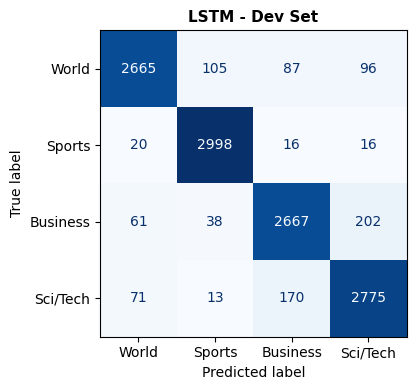

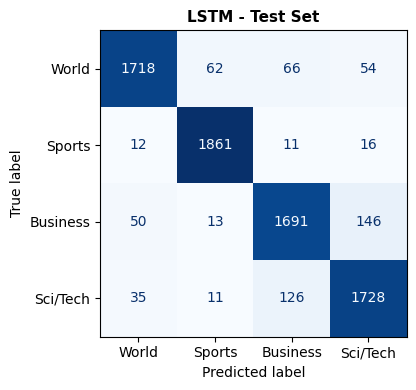

In [35]:
# LSTM
plot_confusion_matrix(res_lstm["val"]["y_true"],  res_lstm["val"]["y_pred"],  "LSTM - Dev Set")
plot_confusion_matrix(res_lstm["test"]["y_true"], res_lstm["test"]["y_pred"], "LSTM - Test Set")

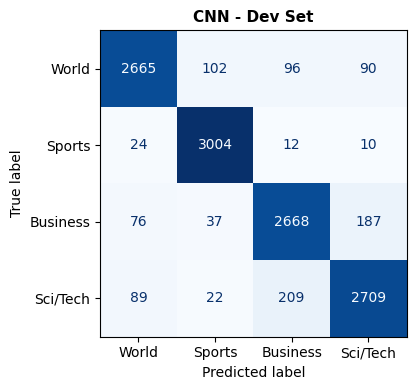

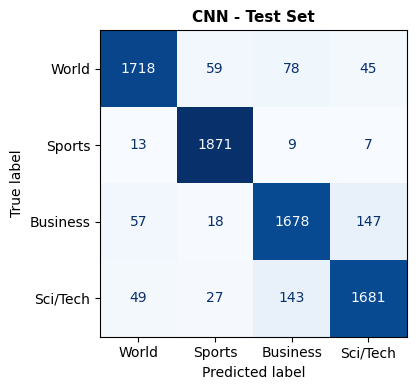

In [36]:
# CNN
plot_confusion_matrix(res_cnn["val"]["y_true"],  res_cnn["val"]["y_pred"],  "CNN - Dev Set")
plot_confusion_matrix(res_cnn["test"]["y_true"], res_cnn["test"]["y_pred"], "CNN - Test Set")

### Plot learning curves for both models

In [37]:
def plot_learning_curves_split(res):
    """Plot train loss vs validation loss for one model."""
    hist = res["hist"]
    epochs    = [h["epoch"]      for h in hist]
    train_loss = [h["train_loss"] for h in hist]
    val_loss   = [h["val_loss"]   for h in hist]

    plt.figure(figsize=(6, 4))
    plt.title(res["name"], fontsize=13, fontweight="bold")

    plt.plot(epochs, train_loss, marker="o", label="Train Loss", color="steelblue")
    plt.plot(epochs, val_loss, marker="o", label="Validation Loss", color="darkorange")

    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

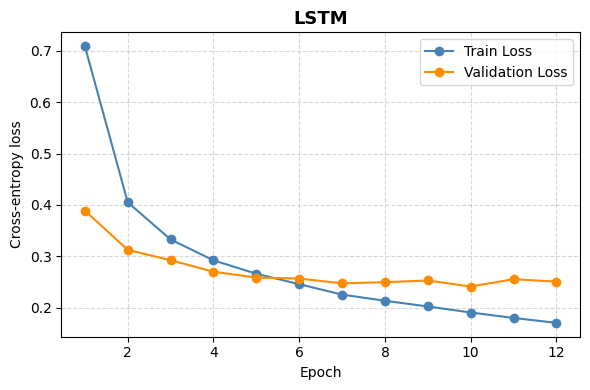

In [38]:
plot_learning_curves_split(res_lstm)

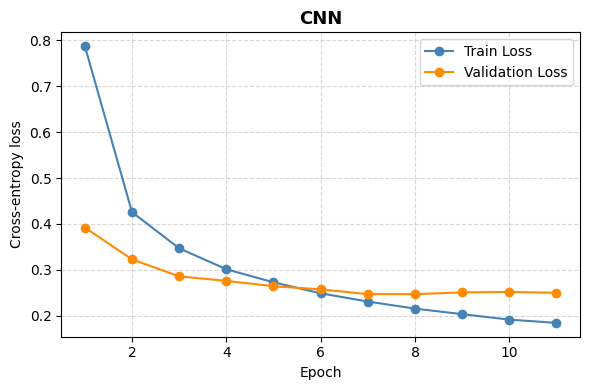

In [39]:
plot_learning_curves_split(res_cnn)

### Ablation study -> dropout 0, 0.3, 0.5

In [40]:
def run_ablation_dropout(dropout: float, seed: int = 13) -> tuple:
    set_seed(seed)

    lstm_model = LSTMClassifier(
        vocab_size=vocab_size,
        embed_dim=64,
        hidden_dim=64,
        num_layers=2,
        dropout=dropout,
        pad_idx=PAD_IDX,
    ).to(device)

    cnn_model = CNNTextClassifier(
        vocab_size=vocab_size,
        embed_dim=64,
        num_filters=64,
        kernel_sizes=(3, 4, 5),
        dropout=dropout,
        pad_idx=PAD_IDX,
    ).to(device)

    hist_lstm = fit(lstm_model, train_loader, val_loader, lr=LR,
                    max_epochs=MAX_EPOCHS, patience=PATIENCE, clip_grad_norm=CLIP)
    hist_cnn  = fit(cnn_model,  train_loader, val_loader, lr=LR,
                    max_epochs=MAX_EPOCHS, patience=PATIENCE, clip_grad_norm=CLIP)

    return {
        "dropout": dropout,
        "lstm": {"model": lstm_model, "hist": hist_lstm,
                 "val": evaluate(lstm_model, val_loader),
                 "test": evaluate(lstm_model, test_loader)},
        "cnn":  {"model": cnn_model,  "hist": hist_cnn,
                 "val": evaluate(cnn_model,  val_loader),
                 "test": evaluate(cnn_model,  test_loader)},
    }


ablation_d0  = run_ablation_dropout(dropout=0.0)
ablation_d03 = run_ablation_dropout(dropout=0.3)  # matches trained baselines
ablation_d05 = run_ablation_dropout(dropout=0.5)

epoch 01 | train loss 0.5714 acc 0.7829 | val loss 0.3688 acc 0.8752 f1 0.8748 | grad norm mean 1.81 max 12.06 | time 273.7s
epoch 02 | train loss 0.3062 acc 0.8998 | val loss 0.2966 acc 0.9008 f1 0.9003 | grad norm mean 1.34 max 7.12 | time 263.8s
epoch 03 | train loss 0.2399 acc 0.9239 | val loss 0.2800 acc 0.9076 f1 0.9073 | grad norm mean 1.06 max 6.35 | time 261.2s
epoch 04 | train loss 0.1970 acc 0.9380 | val loss 0.2872 acc 0.9063 f1 0.9064 | grad norm mean 0.93 max 5.08 | time 255.0s
epoch 05 | train loss 0.1621 acc 0.9499 | val loss 0.2797 acc 0.9128 f1 0.9124 | grad norm mean 0.84 max 3.17 | time 257.3s
epoch 06 | train loss 0.1342 acc 0.9589 | val loss 0.2843 acc 0.9125 f1 0.9120 | grad norm mean 0.81 max 4.65 | time 262.1s
epoch 07 | train loss 0.1086 acc 0.9668 | val loss 0.3160 acc 0.9097 f1 0.9095 | grad norm mean 0.76 max 5.24 | time 270.0s
epoch 08 | train loss 0.0875 acc 0.9728 | val loss 0.3268 acc 0.9104 f1 0.9099 | grad norm mean 0.74 max 5.98 | time 271.9s
Early s

In [41]:
rows = []
for result in [ablation_d0, ablation_d03, ablation_d05]:
    d = result["dropout"]
    for arch in ["lstm", "cnn"]:
        r = result[arch]
        rows.append({
            "model":       arch.upper(),
            "dropout":     d,
            "val_acc":     round(r["val"]["acc"], 4),
            "val_macro_f1": round(r["val"]["f1"], 4),
            "test_acc":    round(r["test"]["acc"], 4),
            "test_macro_f1": round(r["test"]["f1"], 4),
        })

df_ablation = (
    pd.DataFrame(rows)
    .sort_values(["model", "dropout"])
    .reset_index(drop=True)
)
display(df_ablation)

,model,dropout,val_acc,val_macro_f1,test_acc,test_macro_f1
0,CNN,0.0,0.8936,0.8928,0.8876,0.8873
1,CNN,0.3,0.9219,0.9215,0.9183,0.9182
2,CNN,0.5,0.9224,0.9220,0.9161,0.9158
3,LSTM,0.0,0.9128,0.9124,0.9084,0.9083
4,LSTM,0.3,0.9254,0.9251,0.9208,0.9207
5,LSTM,0.5,0.9226,0.9222,0.9199,0.9198


In [42]:
print("FROM TUTORIAL NOTEBOOK")
print("You should interpret the results in terms of bias and variance.")
print("- If dropout 0.0 does well on training but worse on validation, it suggests overfitting. However, the effect of overfitting is not as pronounced here as early stopping effecively is a form of regularization as well. Try running the pipeline without early stopping and compare these results again.")
print("- Note that together with early stopping, dropout of 0.5 might hurt both validation and test, and therefore suggests underfitting.")
print("- If an intermediate dropout does best, it suggests a useful regularization strength for this model and data size.")

FROM TUTORIAL NOTEBOOK
You should interpret the results in terms of bias and variance.
- If dropout 0.0 does well on training but worse on validation, it suggests overfitting. However, the effect of overfitting is not as pronounced here as early stopping effecively is a form of regularization as well. Try running the pipeline without early stopping and compare these results again.
- Note that together with early stopping, dropout of 0.5 might hurt both validation and test, and therefore suggests underfitting.
- If an intermediate dropout does best, it suggests a useful regularization strength for this model and data size.


### Error analysis of original models (ignoring ablation study)

In [43]:
# TODO: Note, that maybe we should adjust this to the best model from the ablation study

In [44]:
LABEL_NAMES_MAP = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

def get_misclassified_df(model: nn.Module, hf_split, max_items: int = 20) -> pd.DataFrame:
    """Return a DataFrame of up to max_items misclassified examples."""
    model.eval()
    rows = []
    for ex in hf_split:
        tokens = tokenize(ex["title"] + " " + ex["description"])
        ids = numericalize(tokens, vocab)[:200]
        if len(ids) == 0:
            ids = [vocab[UNK]]
        x       = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
        lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)

        # Labels in the raw HF dataset are 1-indexed; shift to 0-indexed
        y_true = int(ex["label"]) - 1

        with torch.no_grad():
            logits = model(x, lengths)
            y_pred = int(logits.argmax(dim=1).item())

        if y_pred != y_true:
            snippet = (ex["title"] + " — " + ex["description"]).replace("\n", " ")
            rows.append({
                "title":      ex["title"][:120],
                "description": ex["description"][:200],
                "true_label": LABEL_NAMES_MAP[y_true],
                "pred_label": LABEL_NAMES_MAP[y_pred],
            })

        if len(rows) >= max_items:
            break

    return pd.DataFrame(rows)


pd.set_option("display.max_colwidth", None)

In [45]:
errors_lstm = get_misclassified_df(lstm, test_set, max_items=20)
print("LSTM")
print(f"Showing first {len(errors_lstm)} misclassified examples from test set")
display(errors_lstm)

LSTM
Showing first 20 misclassified examples from test set


,title,description,true_label,pred_label
0,"Card fraud unit nets 36,000 cards","In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards and 171 arrests - and estimates it saved 65m.",Sci/Tech,Business
1,IBM to hire even more new workers,"By the end of the year, the computing giant plans to have its biggest headcount since 1991.",Sci/Tech,Business
2,Some People Not Eligible to Get in on Google IPO,"Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open pro",Sci/Tech,Business
3,Rivals Try to Turn Tables on Charles Schwab,"By MICHAEL LIEDTKE SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped",Sci/Tech,Business
4,Venezuela Prepares for Chavez Recall Vote,Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market.,World,Business
5,Promoting a Shared Vision,"As Michael Kaleko kept running into people who were getting older and having more vision problems, he realized he could do something about it.",Sci/Tech,Business
6,Live: Olympics day four,Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.,World,Sports
7,Intel to delay product aimed for high-definition TVs,"SAN FRANCISCO -- In the latest of a series of product delays, Intel Corp. has postponed the launch of a video display chip it had previously planned to introduce by year end, putting off a showdown wi",Business,Sci/Tech
8,U.S. Misses Cut in Olympic 100 Free,"ATHENS, Greece - Top American sprinters Jason Lezak and Ian Crocker missed the cut in the Olympic 100-meter freestyle preliminaries Tuesday, a stunning blow for a country that had always done well in",World,Sports
9,Surviving Biotech's Downturns,Charly Travers offers advice on withstanding the volatility of the biotech sector.,Business,Sci/Tech


In [46]:
errors_cnn = get_misclassified_df(cnn, test_set, max_items=20)
print("\nCNN")
print(f"Showing first {len(errors_cnn)} misclassified examples from test set")
display(errors_cnn)


CNN
Showing first 20 misclassified examples from test set


,title,description,true_label,pred_label
0,Prediction Unit Helps Forecast Wildfires (AP),"AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he",Sci/Tech,Sports
1,"Card fraud unit nets 36,000 cards","In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards and 171 arrests - and estimates it saved 65m.",Sci/Tech,Business
2,Super ant colony hits Australia,"A giant 100km colony of ants which has been discovered in Melbourne, Australia, could threaten local insect species.",Sci/Tech,World
3,IBM to hire even more new workers,"By the end of the year, the computing giant plans to have its biggest headcount since 1991.",Sci/Tech,Business
4,Some People Not Eligible to Get in on Google IPO,"Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open pro",Sci/Tech,Business
5,Rivals Try to Turn Tables on Charles Schwab,"By MICHAEL LIEDTKE SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tipped",Sci/Tech,Business
6,Jackson Squares Off With Prosecutor,"SANTA MARIA, Calif. - Fans of Michael Jackson erupted in cheers Monday as the pop star emerged from a double-decker tour bus and went into court for a showdown with the prosecutor who has pursued him",World,Sports
7,Live: Olympics day four,Richard Faulds and Stephen Parry are going for gold for Great Britain on day four in Athens.,World,Sports
8,Intel to delay product aimed for high-definition TVs,"SAN FRANCISCO -- In the latest of a series of product delays, Intel Corp. has postponed the launch of a video display chip it had previously planned to introduce by year end, putting off a showdown wi",Business,Sci/Tech
9,Surviving Biotech's Downturns,Charly Travers offers advice on withstanding the volatility of the biotech sector.,Business,Sci/Tech
